In [175]:
import json
import re
from utils.gait_parameters_extractor_raw import (
    GaitParametersExtractorRaw,
    CoordinatesIdx,
)

with open("./datasets/mocap/dataset_mocap_cycles_split.json", "r") as file:
    sequence_cycles = json.load(file)

In [2]:
sequence_cycles['p1s1c0'][0]

{'lfemur': [8.636361122131348, 3.2603681087493896, -0.04507499933242798],
 'ltibia': [7.651093482971191, 1.7556756734848022, -0.2886623740196228],
 'lfoot': [7.5678863525390625, 0.20506787300109863, -0.26919037103652954],
 'ltoes': [7.064680099487305, 0.16790089011192322, -0.3366137146949768],
 'rfemur': [8.733498573303223, 3.2108194828033447, -1.0741034746170044],
 'rtibia': [9.425844192504883, 1.5164947509765625, -0.8321117758750916],
 'rfoot': [10.37553596496582, 0.258259654045105, -0.7889801859855652],
 'rtoes': [9.907983779907227, 0.11361396312713623, -0.7628710865974426],
 'lhumerus': [8.492287635803223, 4.93408203125, 0.05469483137130737],
 'lradius': [8.902358055114746, 3.810229778289795, 0.04463689401745796],
 'lwrist': [8.967071533203125, 3.182685375213623, 0.1379472017288208],
 'rhumerus': [8.376017570495605, 4.924999237060547, -1.0596261024475098],
 'rradius': [8.828798294067383, 3.7279603481292725, -1.208672046661377],
 'rwrist': [8.768996238708496, 3.1097776889801025, -1.

In [3]:
pattern = r"p(\d{1,2})s(\d{1,2})c(\d{1,2})"
combined_participants = []
combined_sequences = []
combined_sequences_parameters = []
involve_hands_parameters = True

for sequence_key, sequence_joint_positions in sequence_cycles.items():
    gpe_raw = GaitParametersExtractorRaw(
        sequence_joint_positions, coordinates_idx=CoordinatesIdx(2, 0, 1),
    )
    if involve_hands_parameters:
        sequence_parameters = gpe_raw.get_gait_parameters()
    else:
        sequence_parameters = gpe_raw.get_gait_parameters_wo_hands()
    match = re.search(pattern, sequence_key)
    participant, sequence, _ = match.groups()

    combined_participants.append(int(participant))
    combined_sequences.append(int(sequence))
    combined_sequences_parameters.append(sequence_parameters)

In [182]:
from utils.gait_parameters_extractor_raw import (
    GaitParametersExtractorRaw,
    CoordinatesIdx,
)

for sequence_key, sequence_joint_positions in sequence_cycles.items():
    gpe_raw = GaitParametersExtractorRaw(
        sequence_joint_positions, coordinates_idx=CoordinatesIdx(2, 0, 1),
    )

    parameter_names = gpe_raw.get_gait_parameters_names()
    break

[param.replace('_', ' ') for param in parameter_names]

['legs angles',
 'left knee angles',
 'right knee angles',
 'left hip angles',
 'right hip angles',
 'left humerus angles',
 'right humerus angles',
 'left elbow angles',
 'right elbow angles',
 'ankle distances',
 'knee distances',
 'elbow distances',
 'hand distances',
 'center of gravity height change',
 'lateral pelvic tilt',
 'pelvis rotation']

In [4]:
print(combined_sequences_parameters[0].shape)
print(len(combined_sequences_parameters))
print(combined_sequences[0])
print(len(combined_sequences))
print(combined_participants[0])
print(len(combined_participants))

(16, 32)
402
1
402
1
402


In [5]:
combined_features_dict = {
    'cloth_1': {person:[] for person in range(1, 33)}, 
    'cloth_2': {person:[] for person in range(1, 33)}, 
    'backpack': {person:[] for person in range(1, 33)},
}

for person, sequence, features in zip(combined_participants, combined_sequences, combined_sequences_parameters):
    if sequence > 8:
        combined_features_dict['backpack'][person].append(features.tolist())
    elif sequence > 4:
        combined_features_dict['cloth_2'][person].append(features.tolist())
    else:
        combined_features_dict['cloth_1'][person].append(features.tolist())
     
# with open("./datasets/mocap/dataset_person_feature.json", "w") as f:
#     json.dump(combined_features_dict, f, indent=4)

In [5]:
import json

with open("./datasets/mocap/dataset_person_feature.json", "r") as file:
    sequences_features = json.load(file)

In [6]:
import numpy as np

np.array(sequences_features['cloth_1']['1'][0]).shape

(16, 32)

In [7]:
import random
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from typing import Sequence, Mapping, Literal


class GaitDataset(Dataset):
    def __init__(
        self,
        sequences_features: Mapping[str, Sequence],
        sequence_length: int = 32,
        feature_dim: int = 16,
    ):
        self.sequences_features = sequences_features
        self.sequence_length = sequence_length
        self.feature_dim = feature_dim
        self.data = []

        self.prepare_data()


    def prepare_data(self):
        for participant, features_set in self.sequences_features.items():
            for features in features_set:
                self.data.append(
                    (
                        np.array(features).astype(np.float32),
                        torch.tensor(int(participant)-1),
                    )
                )

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [8]:
gd_cloth_1 = GaitDataset(sequences_features=sequences_features['cloth_1'])
gd_cloth_2 = GaitDataset(sequences_features=sequences_features['cloth_2'])

In [9]:
print(len(gd_cloth_1))
print(len(gd_cloth_2))

336
66


In [219]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_topk(model, dataloader, ks=(1,2,3)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    max_k = max(ks)

    correct = {k: 0 for k in ks}
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            _, pred = logits.topk(max_k, dim=1, largest=True, sorted=True)

            y = y.view(-1, 1)
            matches = pred.eq(y)

            for k in ks:
                correct[k] += matches[:, :k].any(dim=1).sum().item()

            total += y.size(0)

    return {k: correct[k] / total for k in ks}


def plot_confusion_matrix(model, dataloader, num_classes=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    

    cm = confusion_matrix(all_labels, all_preds, labels=range(32))

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, 
               interpolation='nearest',
               cmap=LinearSegmentedColormap.from_list(
                   "brownish", ["white", "#54290b"]
               ),
    )
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks)
    plt.yticks(tick_marks)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [144]:
import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_size, num_classes=32):
        super(Model, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(), 
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

In [145]:
torch.cuda.is_available()

True

In [130]:
# from torch.utils.data import DataLoader
# import torch

# num_epochs = 300
# learning_rate = 1e-4

# train_loader = DataLoader(
#     gd_cloth_1,
#     batch_size=32,
#     shuffle=True,
# )

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = Model(input_size=16, num_classes=32)
# model = model.to(device)
# criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=learning_rate,
#     weight_decay=1e-4
# )

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for inputs, labels in train_loader:
        
#         inputs = inputs.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()
#         _, predicted = torch.max(outputs, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

#     epoch_loss = running_loss / len(train_loader)
#     epoch_acc = correct / total

#     print(f"Epoch [{epoch+1}/{num_epochs}] "
#           f"Loss: {epoch_loss:.4f} "
#           f"Accuracy: {epoch_acc:.4f}")

Epoch [1/500] Train Loss: 3.4388 Train Acc: 0.0483 Val Loss: 3.4568
Epoch [2/500] Train Loss: 3.2995 Train Acc: 0.0892 Val Loss: 3.4560
Epoch [3/500] Train Loss: 3.2083 Train Acc: 0.1524 Val Loss: 3.3902
Epoch [4/500] Train Loss: 3.1473 Train Acc: 0.1970 Val Loss: 3.3154
Epoch [5/500] Train Loss: 3.0583 Train Acc: 0.2193 Val Loss: 3.2540
Epoch [6/500] Train Loss: 3.0020 Train Acc: 0.2342 Val Loss: 3.1912
Epoch [7/500] Train Loss: 2.8990 Train Acc: 0.3048 Val Loss: 3.1369
Epoch [8/500] Train Loss: 2.8262 Train Acc: 0.3346 Val Loss: 3.0718
Epoch [9/500] Train Loss: 2.7756 Train Acc: 0.2974 Val Loss: 3.0082
Epoch [10/500] Train Loss: 2.6707 Train Acc: 0.3346 Val Loss: 2.9605
Epoch [11/500] Train Loss: 2.6462 Train Acc: 0.3457 Val Loss: 2.9038
Epoch [12/500] Train Loss: 2.5463 Train Acc: 0.3717 Val Loss: 2.8503
Epoch [13/500] Train Loss: 2.5277 Train Acc: 0.3866 Val Loss: 2.7935
Epoch [14/500] Train Loss: 2.4486 Train Acc: 0.4015 Val Loss: 2.7333
Epoch [15/500] Train Loss: 2.3422 Train Acc

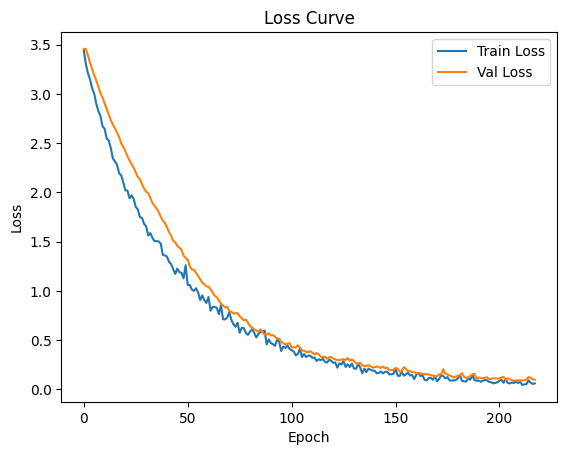

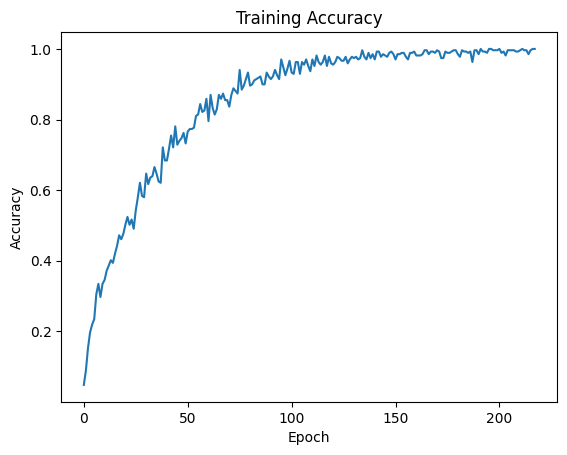

In [187]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch

num_epochs = 500
learning_rate = 1e-4
dataset = gd_cloth_1

train_loader = DataLoader(
    gd_cloth_1,
    batch_size=32,
    shuffle=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(input_size=16, num_classes=32)
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(
#       model.parameters(), 
#     lr=learning_rate
# )
learning_rate = 1e-5
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=learning_rate,
    momentum=0.9
)
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=learning_rate,
#     weight_decay=1e-4
# )

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

best_val_loss = float("inf")
patience = 10
counter = 0

train_losses = []
val_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_loss:.4f} "
        f"Train Acc: {epoch_acc:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "models/best_model_conv1d.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break


plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()


plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [188]:
test_loader = DataLoader(
    gd_cloth_2,
    batch_size=32,
    shuffle=True,
)

evaluate_topk(model, test_loader)

{1: 0.8333333333333334, 2: 0.8787878787878788, 3: 0.8939393939393939}

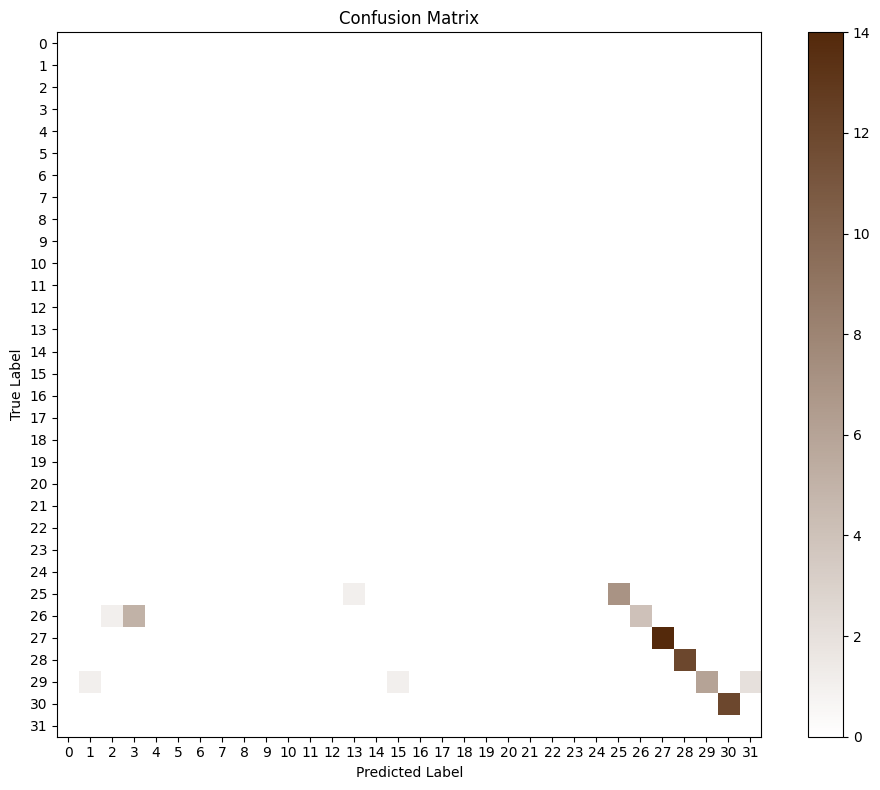

In [220]:
plot_confusion_matrix(model, test_loader)

In [112]:
# ! pip install captum

In [199]:
import torch
from captum.attr import IntegratedGradients

def explain_model_captum_full(model, dataloader, n_batches=None):
    model.eval()
    ig = IntegratedGradients(model)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    total_channel_importance = None
    total_step_importance = None
    total_features_heatmap = None
    samples_processed = 0

    for i, (x, y) in enumerate(dataloader):
        if n_batches and i >= n_batches:
            break
            
        x, y = x.to(device), y.to(device)
        x.requires_grad_()

        # attributions shape: (batch, input_size, seq_len)
        attributions = ig.attribute(x, target=y, n_steps=100).abs()

        # Importance per feature
        # Mean over seq_len, then sum over batch
        batch_channel = attributions.mean(dim=2).sum(dim=0)

        # Importance per time-step
        # Mean over input_size (channels), then sum over batch
        batch_steps = attributions.mean(dim=1).sum(dim=0)

        features_heatmap = attributions.sum(dim=0)

        if total_channel_importance is None:
            total_channel_importance = batch_channel.detach().cpu()
            total_step_importance = batch_steps.detach().cpu()
            total_features_heatmap = features_heatmap.detach().cpu()
        else:
            total_channel_importance += batch_channel.detach().cpu()
            total_step_importance += batch_steps.detach().cpu()
            total_features_heatmap += features_heatmap.detach().cpu()

        samples_processed += x.size(0)

    avg_channel_imp = (total_channel_importance / samples_processed).numpy()
    avg_step_imp = (total_step_importance / samples_processed).numpy()
    avg_features_heatmap = (total_features_heatmap / samples_processed).numpy()
    
    return avg_channel_imp, avg_step_imp, avg_features_heatmap

In [256]:
import matplotlib.pyplot as plt

def plot_feature_importance(importance_scores, feature_names=None):
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(len(importance_scores))]
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_names, importance_scores, color='skyblue')
    plt.xlabel("Mean Absolute Attribution (Importance)")
    plt.ylabel("Input Channels")
    plt.title("Global Feature Importance (Integrated Gradients)")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig('plots/explainable_elements/feature_importance_mocap.pdf')
    plt.show()

def plot_frame_importance(step_scores):
    plt.figure(figsize=(10, 4))
    plt.bar(list(range(32)), step_scores, color="orange", linewidth=2)
    
    plt.title("Temporal Importance (Integrated Gradients)")
    plt.xlabel("Frame")
    plt.ylabel("Mean Absolute Attribution (Importance)")
    plt.grid(True, alpha=0.3)
    plt.savefig('plots/explainable_elements/frame_importance_mocap.pdf')
    plt.show()


def plot_frame_feature_heatmap(features_heatmap, feature_names=None):
    plt.figure(figsize=(10, 4))
    plt.imshow(features_heatmap, 
               interpolation='nearest',
               cmap=LinearSegmentedColormap.from_list(
                   "brownish", ["white", "#54290b"]
               ),
    )
    plt.title("Importance Heatmap (Integrated Gradients)")
    plt.colorbar()
    plt.xlabel("Frame")
    plt.ylabel("Feature")
    plt.savefig('plots/explainable_elements/importance_heatmap_mocap.pdf')
    plt.show()
    

In [257]:
feature_names = ['legs angle',
 'left knee angle',
 'right knee angle',
 'left hip angle',
 'right hip angle',
 'left humerus angle',
 'right humerus angle',
 'left elbow angle',
 'right elbow angle',
 'ankle distance',
 'knee distance',
 'elbow distance',
 'hand distance',
 'center of gravity height change',
 'lateral pelvic tilt',
 'pelvis rotation']

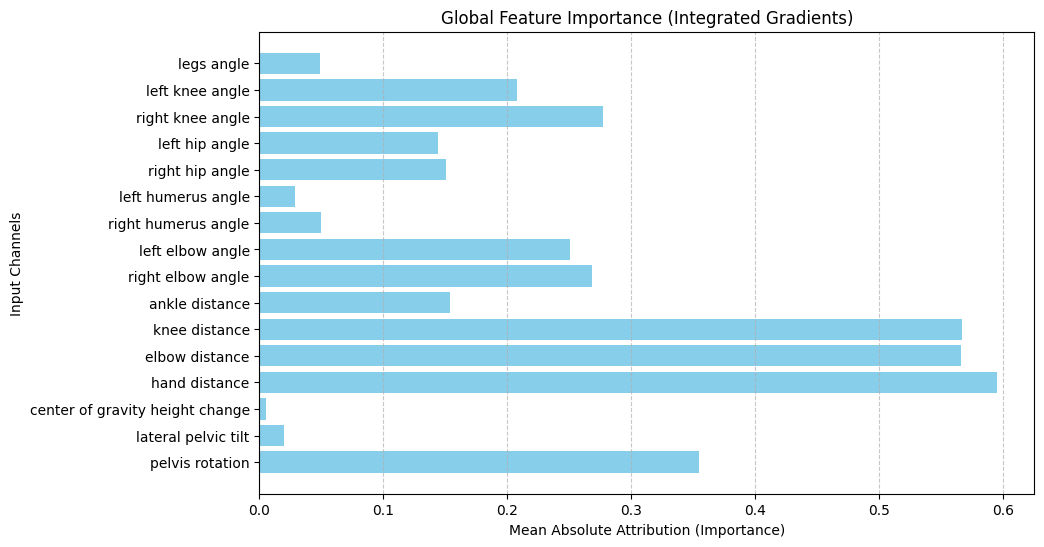

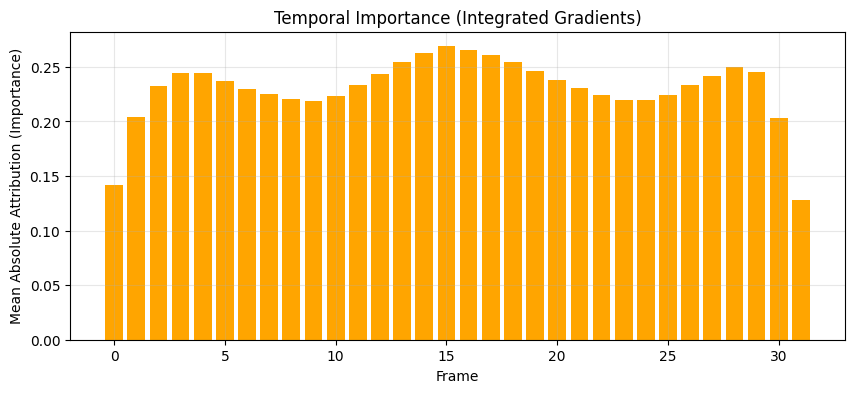

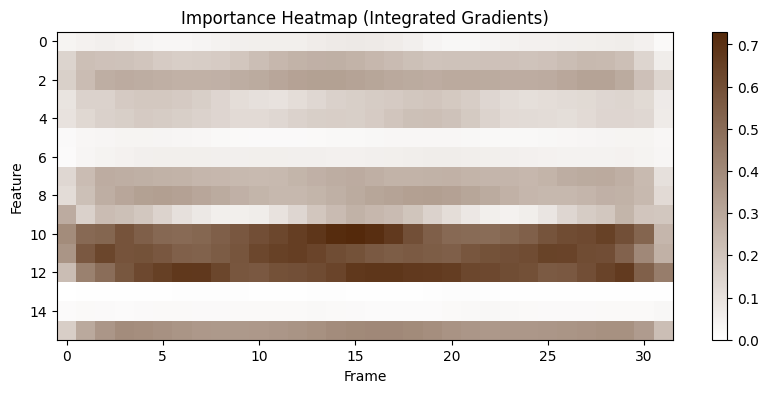

In [258]:
avg_channel_imp, avg_step_imp, avg_features_heatmap = explain_model_captum_full(model, test_loader)
plot_feature_importance(avg_channel_imp, feature_names)
plot_frame_importance(avg_step_imp)
plot_frame_feature_heatmap(avg_features_heatmap)